# Lezione 3 — metodi, una cella alla volta

Ogni cella è indipendente: costruisce i propri dati, esegue una sola operazione e ne stampa
il risultato. Si esegue in qualsiasi ordine. Servono solo `numpy`, `pandas`, `scikit-learn`
e `matplotlib`.

Dati sintetici: fissano la forma del fenomeno, non riportano misure reali.

## 1 · Windowing

Una serie diventa una matrice di finestre sovrapposte.

serie       (600,)
finestre    (34, 64) = 34 finestre da 64 campioni, passo 16
sovrapposizione fra finestre consecutive: 48 campioni
un campione compare in 4 finestre


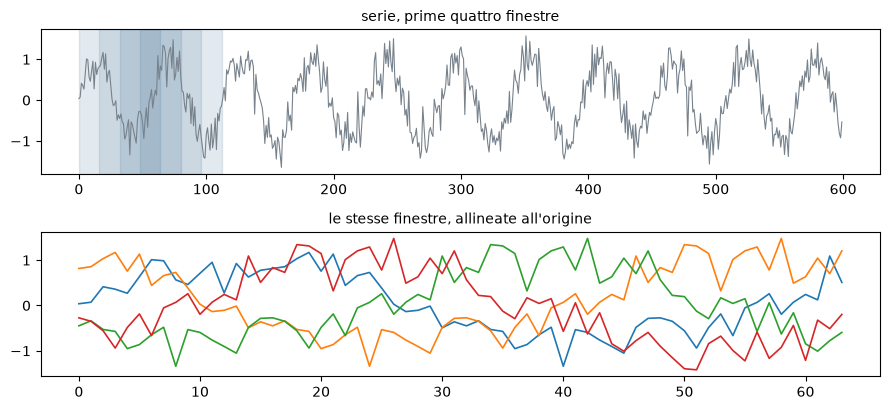

In [1]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(0)
N, L, PASSO = 600, 64, 16
t = np.arange(N)
serie = np.sin(t / 9) + 0.3 * rng.normal(size=N)

idx = np.arange(0, N - L + 1, PASSO)
finestre = np.stack([serie[i:i + L] for i in idx])

print("serie      ", serie.shape)
print("finestre   ", finestre.shape, f"= {len(idx)} finestre da {L} campioni, passo {PASSO}")
print("sovrapposizione fra finestre consecutive:", L - PASSO, "campioni")
print("un campione compare in", L // PASSO, "finestre")

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2))
ax[0].plot(t, serie, lw=.8, color="#77828c")
for i in idx[:4]:
    ax[0].axvspan(i, i + L, alpha=.13, color="#2c5f8a")
ax[0].set_title("serie, prime quattro finestre", fontsize=10)
for f in finestre[:4]:
    ax[1].plot(f, lw=1.2)
ax[1].set_title("le stesse finestre, allineate all'origine", fontsize=10)
fig.tight_layout(); plt.show()

## 2 · Split dei dati

L'etichetta dipende solo dall'unità. Il taglio determina che cosa la valutazione misura.

In [2]:
import numpy as np, pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(1)
U, T = 100, 100

livello = np.arange(U) * 5.0                 # il valore di x identifica l'unita
classe  = (rng.random(U) < .5).astype(int)   # etichetta assegnata all'unita, non al tempo

d = pd.concat([pd.DataFrame({"unita": u, "tempo": np.arange(T),
                             "x": livello[u] + np.cumsum(rng.normal(0, .05, T)),
                             "y": classe[u]}) for u in range(U)], ignore_index=True)

X, y = d[["x"]].values, d["y"].values
i = np.arange(len(d))

def accuratezza(tr, te):
    return KNeighborsClassifier(5).fit(X[tr], y[tr]).score(X[te], y[te])

tr, te = train_test_split(i, test_size=.3, random_state=0, shuffle=True)
a_casuale = accuratezza(tr, te)
a_tempo   = accuratezza(i[(d.tempo < 70).values], i[(d.tempo >= 70).values])

a_unita = []
for seme in range(10):                       # dieci partizioni diverse delle unita
    u_tr = np.random.default_rng(seme).permutation(U)[:70]
    dentro = d.unita.isin(u_tr).values
    a_unita.append(accuratezza(i[dentro], i[~dentro]))

print(f"split casuale    {a_casuale:.3f}")
print(f"split per tempo  {a_tempo:.3f}")
print(f"split per unita  {np.mean(a_unita):.3f}   (fra {min(a_unita):.3f} e {max(a_unita):.3f} su dieci partizioni)")
print()
print("L'etichetta e' assegnata all'unita e il livello di x identifica l'unita.")
print("Nei primi due split la stessa unita compare in addestramento e in test, e il modello")
print("ritrova l'etichetta che ha memorizzato. Il caso vale 0.5.")

split casuale    1.000
split per tempo  1.000
split per unita  0.459   (fra 0.386 e 0.515 su dieci partizioni)

L'etichetta e' assegnata all'unita e il livello di x identifica l'unita.
Nei primi due split la stessa unita compare in addestramento e in test, e il modello
ritrova l'etichetta che ha memorizzato. Il caso vale 0.5.


## 3 · Normalizzazione: statistiche sul riferimento o su tutta la serie

La seconda incorpora nel modello il periodo che dovrebbe valutare.

su tutta la serie   media   1.20   scarto  1.88
sul riferimento     media  -0.05   scarto  1.02

|z| massimo         tutta la serie  2.89   riferimento  6.59
campioni oltre 3    tutta la serie     0   riferimento   235


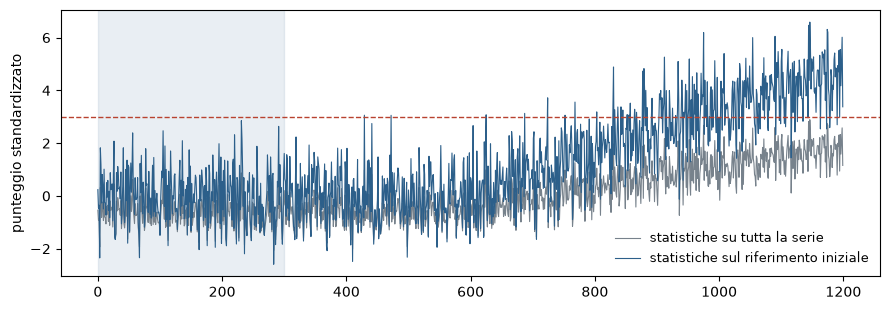

In [3]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(2)
N, RIF = 1200, 300
serie = rng.normal(0, 1, N) + np.r_[np.zeros(600), np.linspace(0, 5, N - 600)]

z_tutto = (serie - serie.mean()) / serie.std()
m, s = serie[:RIF].mean(), serie[:RIF].std()
z_rif = (serie - m) / s

print(f"su tutta la serie   media {serie.mean():6.2f}   scarto {serie.std():5.2f}")
print(f"sul riferimento     media {m:6.2f}   scarto {s:5.2f}")
print()
print(f"|z| massimo         tutta la serie {np.abs(z_tutto).max():5.2f}   riferimento {np.abs(z_rif).max():5.2f}")
print(f"campioni oltre 3    tutta la serie {(np.abs(z_tutto) > 3).sum():5d}   riferimento {(np.abs(z_rif) > 3).sum():5d}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(z_tutto, lw=.8, color="#77828c", label="statistiche su tutta la serie")
ax.plot(z_rif, lw=.8, color="#2c5f8a", label="statistiche sul riferimento iniziale")
ax.axhline(3, ls="--", lw=1, color="#b8422f")
ax.axvspan(0, RIF, alpha=.10, color="#2c5f8a")
ax.set_ylabel("punteggio standardizzato"); ax.legend(fontsize=9, frameon=False)
fig.tight_layout(); plt.show()

## 4 · Ricampionamento e valori mancanti

L'interpolazione produce valori mai misurati. Un indicatore di presenza li distingue.

In [4]:
import numpy as np, pandas as pd

rng = np.random.default_rng(3)
n = 400
t0 = pd.Timestamp("2026-01-01")
t = t0 + pd.to_timedelta(np.sort(rng.uniform(0, 3600, n)), unit="s")
v = 20 + np.sin(np.arange(n) / 25) + rng.normal(0, .05, n)
s = pd.Series(v, index=t)

# interruzione dell'acquisizione fra il minuto 15 e il minuto 25
s = s[(s.index < t0 + pd.Timedelta("900s")) | (s.index > t0 + pd.Timedelta("1500s"))]

g = s.resample("30s").mean()
d = pd.DataFrame({"valore": g, "presente": g.notna().astype(int)})
d["interpolato"] = g.interpolate()

print("campioni originali", len(s), " -> griglia a 30 s", len(g), " di cui mancanti", int(g.isna().sum()))
print()
print(d.iloc[28:38].round(3))
print()
print("La colonna 'interpolato' non ha buchi e nessuno dei suoi valori nel buco e' stato misurato.")
print("La colonna 'presente' conserva l'informazione che l'interpolazione cancella.")

campioni originali 335  -> griglia a 30 s 120  di cui mancanti 22

                     valore  presente  interpolato
2026-01-01 00:14:00  19.566         1       19.566
2026-01-01 00:14:30  19.412         1       19.412
2026-01-01 00:15:00     NaN         0       19.449
2026-01-01 00:15:30     NaN         0       19.486
2026-01-01 00:16:00     NaN         0       19.523
2026-01-01 00:16:30     NaN         0       19.561
2026-01-01 00:17:00     NaN         0       19.598
2026-01-01 00:17:30     NaN         0       19.635
2026-01-01 00:18:00     NaN         0       19.672
2026-01-01 00:18:30     NaN         0       19.710

La colonna 'interpolato' non ha buchi e nessuno dei suoi valori nel buco e' stato misurato.
La colonna 'presente' conserva l'informazione che l'interpolazione cancella.


## 5 · Canali costanti e sensori bloccati

La varianza sull'intera raccolta individua il primo caso e non il secondo.

In [5]:
import numpy as np, pandas as pd

rng = np.random.default_rng(4)
N, BLOCCO = 400, 240
t = np.arange(N)

d = pd.DataFrame({
    "s1": 10 + np.sin(t / 30) + rng.normal(0, .10, N),   # varia
    "s2": rng.normal(5, .40, N),                          # varia
    "s3": np.full(N, 100.0),                              # costante da sempre
    "s4": 2 + np.sin(t / 17) + rng.normal(0, .05, N),     # si blocca a meta'
})
d.loc[BLOCCO:, "s4"] = d.loc[BLOCCO - 1, "s4"]

esito = pd.DataFrame({
    "varianza totale": d.var().round(5),
    "min varianza su finestra 60": d.rolling(60).var().min().round(8),
    "max valori uguali consecutivi": [int((c.diff() == 0).groupby((c.diff() != 0).cumsum()).cumcount().max() + 1)
                                      for _, c in d.items()],
})
print(esito)
print()
print("s3: varianza totale nulla.  s4: varianza totale ordinaria, varianza su finestra nulla.")

    varianza totale  min varianza su finestra 60  \
s1          0.48867                     0.025694   
s2          0.16535                     0.104531   
s3          0.00000                     0.000000   
s4          0.50301                     0.000000   

    max valori uguali consecutivi  
s1                              1  
s2                              1  
s3                            400  
s4                            161  

s3: varianza totale nulla.  s4: varianza totale ordinaria, varianza su finestra nulla.


## 6 · Baseline · punteggio standardizzato robusto

Mediana e scarto mediano assoluto al posto di media e deviazione standard.

classico  media 50.63   scarto 2.73
robusto   mediana 50.04   MAD*1.4826 1.08

punti oltre 3.5   classico  19   robusto  40   iniettati  40

Le anomalie entrano nella media e nella deviazione standard e alzano la soglia contro
cui sono misurate. Mediana e MAD non ne risentono finche' restano meno della meta'.


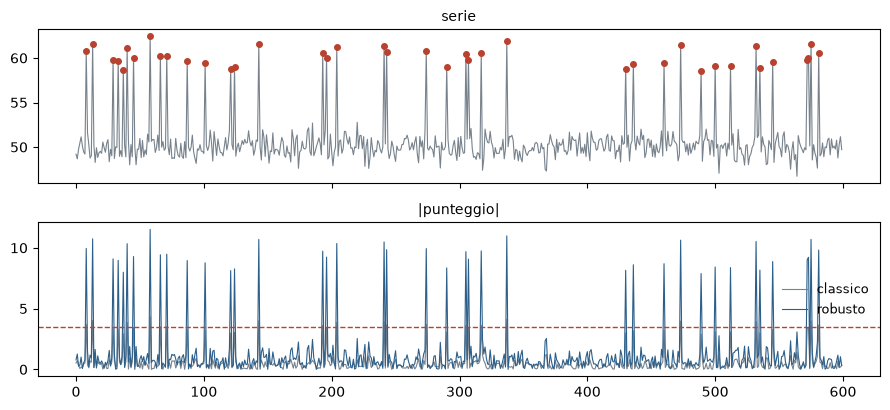

In [6]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(5)
N, N_PICCHI = 600, 40
serie = 50 + rng.normal(0, 1, N)
picchi = np.sort(rng.choice(N, N_PICCHI, replace=False))
serie[picchi] += 10

z = (serie - serie.mean()) / serie.std()
mediana = np.median(serie)
mad = np.median(np.abs(serie - mediana))
z_rob = 0.6745 * (serie - mediana) / mad          # 0.6745 riporta il MAD alla scala normale

print(f"classico  media {serie.mean():.2f}   scarto {serie.std():.2f}")
print(f"robusto   mediana {mediana:.2f}   MAD*1.4826 {mad / 0.6745:.2f}")
print()
print(f"punti oltre 3.5   classico {int((np.abs(z) > 3.5).sum()):3d}   robusto {int((np.abs(z_rob) > 3.5).sum()):3d}   iniettati {len(picchi):3d}")
print()
print("Le anomalie entrano nella media e nella deviazione standard e alzano la soglia contro")
print("cui sono misurate. Mediana e MAD non ne risentono finche' restano meno della meta'.")

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
ax[0].plot(serie, lw=.8, color="#77828c"); ax[0].plot(picchi, serie[picchi], "o", ms=4, color="#b8422f")
ax[0].set_title("serie", fontsize=10)
ax[1].plot(np.abs(z), lw=.8, color="#77828c", label="classico")
ax[1].plot(np.abs(z_rob), lw=.8, color="#2c5f8a", label="robusto")
ax[1].axhline(3.5, ls="--", lw=1, color="#b8422f")
ax[1].set_title("|punteggio|", fontsize=10); ax[1].legend(fontsize=9, frameon=False)
fig.tight_layout(); plt.show()

## 7 · Baseline · CUSUM su drift lento

Accumula gli scarti persistenti. Segnala prima che un singolo campione esca da tre sigma.

inizio del drift                        400
segnalazione CUSUM                      460   (60 campioni dopo l'inizio)
primo campione oltre 3 sigma dall'inizio 488   (88 campioni dopo l'inizio)

scostamento del livello quando CUSUM segnala: 1.14 sigma
falsi allarmi della regola a tre sigma prima del drift: 2
falsi allarmi del CUSUM prima del drift:                0


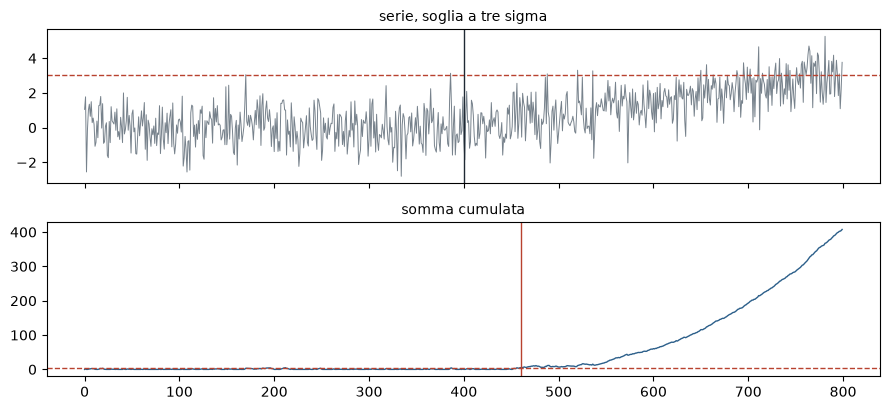

In [7]:
import numpy as np, matplotlib.pyplot as plt

rng = np.random.default_rng(6)
N, INIZIO = 800, 400
serie = rng.normal(0, 1, N)
serie[INIZIO:] += np.linspace(0, 3.0, N - INIZIO)     # drift lento

mu, sigma = serie[:300].mean(), serie[:300].std()     # riferimento
k, h = 0.5, 5.0                                        # scostamento tollerato, soglia
x = (serie - mu) / sigma
alto = np.zeros(N)
for i in range(1, N):
    alto[i] = max(0.0, alto[i - 1] + x[i] - k)

i_cusum = int(np.argmax(alto > h))
oltre = np.flatnonzero(np.abs(x) > 3)
i_sigma = int(oltre[oltre >= INIZIO][0])

print(f"inizio del drift                        {INIZIO}")
print(f"segnalazione CUSUM                      {i_cusum}   ({i_cusum - INIZIO} campioni dopo l'inizio)")
print(f"primo campione oltre 3 sigma dall'inizio {i_sigma}   ({i_sigma - INIZIO} campioni dopo l'inizio)")
print()
print(f"scostamento del livello quando CUSUM segnala: {(serie[i_cusum] - mu) / sigma:.2f} sigma")
print(f"falsi allarmi della regola a tre sigma prima del drift: {int((oltre < INIZIO).sum())}")
print(f"falsi allarmi del CUSUM prima del drift:                {int((alto[:INIZIO] > h).sum())}")

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
ax[0].plot(serie, lw=.7, color="#77828c"); ax[0].axhline(mu + 3 * sigma, ls="--", lw=1, color="#b8422f")
ax[0].axvline(INIZIO, lw=1, color="#1f2933"); ax[0].set_title("serie, soglia a tre sigma", fontsize=10)
ax[1].plot(alto, lw=1, color="#2c5f8a"); ax[1].axhline(h, ls="--", lw=1, color="#b8422f")
ax[1].axvline(i_cusum, lw=1, color="#b8422f"); ax[1].set_title("somma cumulata", fontsize=10)
fig.tight_layout(); plt.show()

## 8 · Isolation Forest

Punteggio dalla profondita' media di isolamento con tagli casuali.

AUC 0.919
punteggio medio  normali 0.426  anomali 0.627


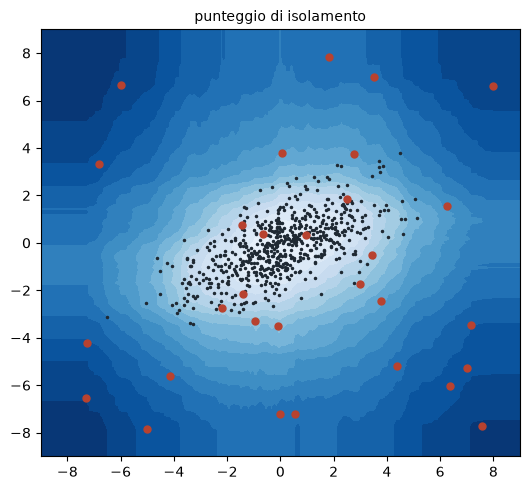

In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(7)
n_norm, n_anom = 600, 30
normali = rng.normal(0, 1, (n_norm, 2)) @ np.array([[2.0, .8], [0, 1.0]])
anomali = rng.uniform(-8, 8, (n_anom, 2))
X = np.vstack([normali, anomali])
vero = np.r_[np.zeros(n_norm), np.ones(n_anom)]

mod = IsolationForest(n_estimators=200, random_state=0).fit(X)
punteggio = -mod.score_samples(X)          # piu' alto = piu' anomalo

print("AUC", round(roc_auc_score(vero, punteggio), 3))
print("punteggio medio  normali", round(punteggio[vero == 0].mean(), 3),
      " anomali", round(punteggio[vero == 1].mean(), 3))

gx, gy = np.meshgrid(np.linspace(-9, 9, 200), np.linspace(-9, 9, 200))
gz = -mod.score_samples(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

fig, ax = plt.subplots(figsize=(5.4, 5))
ax.contourf(gx, gy, gz, levels=18, cmap="Blues")
ax.plot(*normali.T, ".", ms=3, color="#1f2933")
ax.plot(*anomali.T, "o", ms=5, color="#b8422f")
ax.set_title("punteggio di isolamento", fontsize=10)
fig.tight_layout(); plt.show()

## 9 · Local Outlier Factor

Densita' locale del punto contro quella dei suoi vicini. Il confronto e' locale.

distanza dal centro del proprio gruppo, identica nei due casi: 2.2
LOF nel gruppo compatto  5.29
LOF nel gruppo rado      0.99
LOF mediano dei punti ordinari  1.02


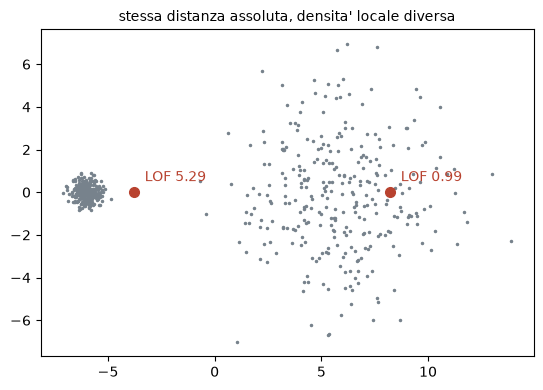

In [9]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

rng = np.random.default_rng(8)
compatto = rng.normal([-6, 0], 0.35, (300, 2))
rado     = rng.normal([ 6, 0], 2.50, (300, 2))

D = 2.2                                   # stessa distanza assoluta dal proprio centro
p_compatto = np.array([[-6 + D, 0.0]])
p_rado     = np.array([[ 6 + D, 0.0]])

X = np.vstack([compatto, rado, p_compatto, p_rado])
lof = LocalOutlierFactor(n_neighbors=20).fit(X)
val = -lof.negative_outlier_factor_

print(f"distanza dal centro del proprio gruppo, identica nei due casi: {D}")
print(f"LOF nel gruppo compatto  {val[-2]:.2f}")
print(f"LOF nel gruppo rado      {val[-1]:.2f}")
print(f"LOF mediano dei punti ordinari  {np.median(val[:-2]):.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*compatto.T, ".", ms=3, color="#77828c"); ax.plot(*rado.T, ".", ms=3, color="#77828c")
for p, v in [(p_compatto, val[-2]), (p_rado, val[-1])]:
    ax.plot(*p.T, "o", ms=7, color="#b8422f")
    ax.annotate(f"LOF {v:.2f}", p[0], textcoords="offset points", xytext=(8, 8), color="#b8422f")
ax.set_aspect("equal"); ax.set_title("stessa distanza assoluta, densita' locale diversa", fontsize=10)
fig.tight_layout(); plt.show()

## 10 · Ricostruzione · autoencoder

Addestrato a ricostruire finestre normali. Il punteggio e' l'errore di ricostruzione.

finestre (3961, 40)  collo di bottiglia 6 su 40
AUC 0.999
errore medio  normali 0.1498  anomali 0.6105


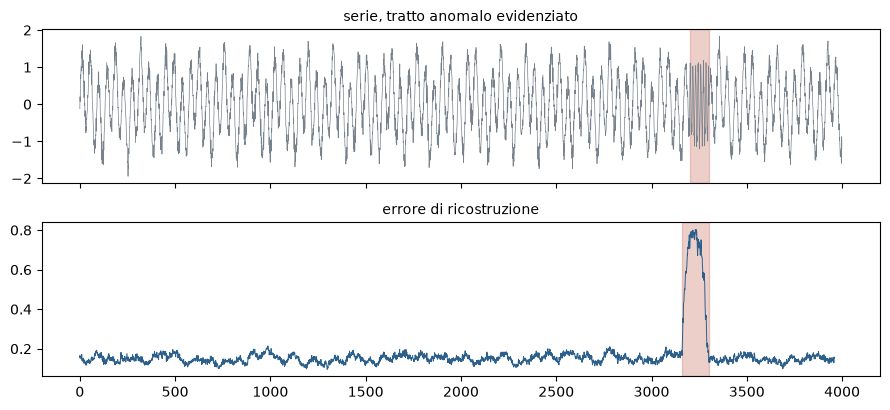

In [10]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(9)
N, L = 4000, 40
t = np.arange(N)
serie = np.sin(t / 7) + .5 * np.sin(t / 23) + .15 * rng.normal(size=N)

A, B = 3200, 3300                                    # dinamica diversa, stessa ampiezza
serie[A:B] = np.sin(np.arange(B - A) / 2.2) + .15 * rng.normal(size=B - A)

X = np.stack([serie[i:i + L] for i in range(N - L + 1)])
vero = np.array([(i < B) and (i + L > A) for i in range(N - L + 1)]).astype(int)
tr = np.arange(2500)                                 # tratto senza anomalie

sc = StandardScaler().fit(X[tr])
Xs = sc.transform(X)
ae = MLPRegressor(hidden_layer_sizes=(24, 6, 24), max_iter=300,
                  random_state=0, early_stopping=False).fit(Xs[tr], Xs[tr])
errore = np.abs(Xs - ae.predict(Xs)).mean(1)

print("finestre", X.shape, " collo di bottiglia 6 su", L)
print("AUC", round(roc_auc_score(vero, errore), 3))
print("errore medio  normali", round(errore[vero == 0].mean(), 4),
      " anomali", round(errore[vero == 1].mean(), 4))

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
ax[0].plot(serie, lw=.5, color="#77828c"); ax[0].axvspan(A, B, alpha=.25, color="#b8422f")
ax[0].set_title("serie, tratto anomalo evidenziato", fontsize=10)
ax[1].plot(errore, lw=.7, color="#2c5f8a"); ax[1].axvspan(A - L, B, alpha=.25, color="#b8422f")
ax[1].set_title("errore di ricostruzione", fontsize=10)
fig.tight_layout(); plt.show()

## 11 · Previsione · residuo

Il modello prevede il campione successivo dalla finestra passata. Il punteggio e' il residuo.

AUC 0.915
residuo medio  normali 0.1369  anomali 0.8307
Il residuo e' nell'unita' della grandezza misurata: una soglia su di esso e' uno scostamento fisico.


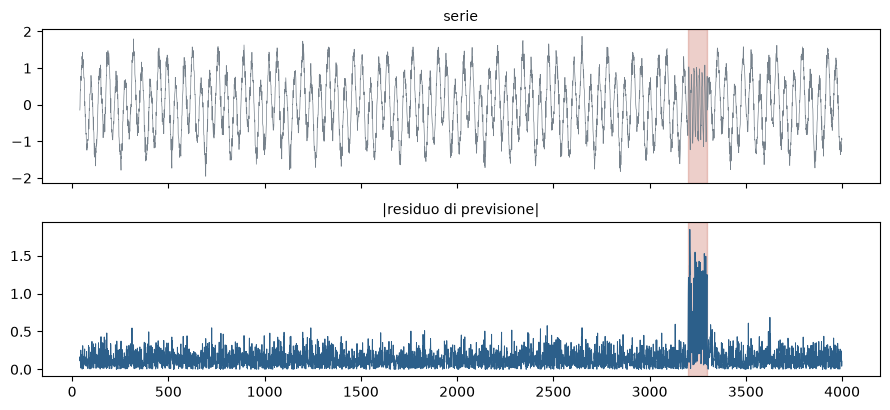

In [11]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(10)
N, L = 4000, 40
t = np.arange(N)
serie = np.sin(t / 7) + .5 * np.sin(t / 23) + .15 * rng.normal(size=N)

A, B = 3200, 3300
serie[A:B] = np.sin(np.arange(B - A) / 2.2) + .15 * rng.normal(size=B - A)

X = np.stack([serie[i:i + L] for i in range(N - L)])   # solo campioni passati
y = serie[L:N]
vero = ((np.arange(L, N) >= A) & (np.arange(L, N) < B)).astype(int)
tr = np.arange(2500)

mod = Ridge(alpha=1.0).fit(X[tr], y[tr])
residuo = np.abs(y - mod.predict(X))

print("AUC", round(roc_auc_score(vero, residuo), 3))
print("residuo medio  normali", round(residuo[vero == 0].mean(), 4),
      " anomali", round(residuo[vero == 1].mean(), 4))
print("Il residuo e' nell'unita' della grandezza misurata: una soglia su di esso e' uno scostamento fisico.")

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
ax[0].plot(np.arange(L, N), y, lw=.5, color="#77828c"); ax[0].axvspan(A, B, alpha=.25, color="#b8422f")
ax[0].set_title("serie", fontsize=10)
ax[1].plot(np.arange(L, N), residuo, lw=.7, color="#2c5f8a"); ax[1].axvspan(A, B, alpha=.25, color="#b8422f")
ax[1].set_title("|residuo di previsione|", fontsize=10)
fig.tight_layout(); plt.show()